# Course NIGK21007U - Integrated Water Resources Modelling
## Tutorial 5

This notebook shows you how to set up and solve a LP water resources optimization model in pyomo. The conceptual model of the system is shown again here:



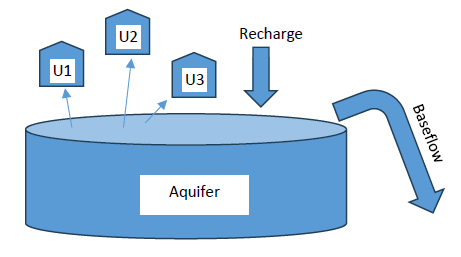

First, import necessary packages:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo

Give the path and filename for the input file:

In [2]:
datafile = r'h:\KU_Courses\NIGK21007U Integrated Water Resources Modelling\2026\Tutorials\Tutorial_5\Tutorial_5.xlsx'

First, read all data from the input file:

In [3]:
data = pd.read_excel(datafile)
data['Baseflow (1000 m3 / week)'] = None
data['Pumping (1000 m3 / week)'] = None
data['Storage (1000 m3)'] = None
data['Allocation 1 (1000 m3 / week)'] = None
data['Allocation 2 (1000 m3 / week)'] = None
data['Allocation 3 (1000 m3 / week)'] = None
data['Benefit (1000 DKK / week)'] = None

K = 15
D1 = 984
D2 = 232
D3 = 234
WTP1 = 90
WTP2 = 45
WTP3 = 30

Slast = 0
BFlast = 0
meanrech = data['Recharge (1000 m3 / week)'].mean()
print('Average recharge: ', meanrech)

ptarget = 1200.
BF = data*np.nan

Average recharge:  2119.8811689600925


Now, the rule-based allocation:

In [4]:
for t in data['Time step'].values:
    pumping = min(Slast + data['Recharge (1000 m3 / week)'][t], ptarget)
    BFnext = BFlast * np.exp(-1/K) + (data['Recharge (1000 m3 / week)'][t]-pumping) * (1-np.exp(-1/K))
    data.loc[t,'Baseflow (1000 m3 / week)'] = BFnext
    data.loc[t,'Pumping (1000 m3 / week)'] = pumping
    Snew = Slast + data['Recharge (1000 m3 / week)'][t] - pumping - BFnext
    data.loc[t,'Storage (1000 m3)'] = Snew
    A1 = min(D1, pumping)
    A2 = min(D2, pumping - A1)
    A3 = min(D3, pumping - A1 - A2)
    Benefit = A1*WTP1 + A2*WTP2 + A3*WTP3
    data.loc[t,'Allocation 1 (1000 m3 / week)'] = A1
    data.loc[t,'Allocation 2 (1000 m3 / week)'] = A2
    data.loc[t,'Allocation 3 (1000 m3 / week)'] = A3
    data.loc[t,'Benefit (1000 DKK / week)'] = Benefit
    Slast = Snew
    BFlast = BFnext
    
meanbf = data['Baseflow (1000 m3 / week)'].mean()
meanben = data['Benefit (1000 DKK / week)'].mean()
print('Average baseflow: ', meanbf)
print('Average benefit: ', meanben)

Average baseflow:  1084.0267611517436
Average benefit:  84515.98313920567


Now, set up the linear program:

In [5]:
#%% Linear Program
time_steps = data.shape[0]
ntimes = np.arange(1, time_steps+1, 1)   # weekly time periods
ntimepoints = np.arange(1, time_steps+2, 1)   # time points separating periods
model = pyo.ConcreteModel()
model.ntimes = pyo.Set(dimen=1,initialize=ntimes) # define time index, set values to ntimes
model.ntimepoints = pyo.Set(dimen=1,initialize=ntimepoints)

model.Allocation1  = pyo.Var(model.ntimes, within=pyo.NonNegativeReals)
model.Allocation2  = pyo.Var(model.ntimes, within=pyo.NonNegativeReals)
model.Allocation3  = pyo.Var(model.ntimes, within=pyo.NonNegativeReals)
model.Baseflow  = pyo.Var(model.ntimepoints, within=pyo.NonNegativeReals)
model.Storage  = pyo.Var(model.ntimepoints, within=pyo.NonNegativeReals)

def obj_rule(model):
    return sum(model.Allocation1[t] for t in model.ntimes) * WTP1 + \
           sum(model.Allocation2[t] for t in model.ntimes) * WTP2 + \
           sum(model.Allocation3[t] for t in model.ntimes) * WTP3
model.obj = pyo.Objective(rule=obj_rule, sense = pyo.maximize)

def IniStor_c(model): # initial GW storage
    return model.Storage[1] == 0
model.IniStor = pyo.Constraint(rule = IniStor_c)

def IniBF_c(model): # initial baseflow
    return model.Baseflow[1] == 0
model.IniBF = pyo.Constraint(rule = IniBF_c)

def Dem1_c(model,t): # Allocation less equal demand
    return model.Allocation1[t] <= D1
model.Dem1 = pyo.Constraint(model.ntimes, rule = Dem1_c)

def Dem2_c(model,t): # Allocation less equal demand
    return model.Allocation2[t] <= D2
model.Dem2 = pyo.Constraint(model.ntimes, rule = Dem2_c)

def Dem3_c(model,t): # Allocation less equal demand
    return model.Allocation3[t] <= D3
model.Dem3 = pyo.Constraint(model.ntimes, rule = Dem3_c)

def BF_c(model,t): # Baseflow from linear reservoir
    return model.Baseflow[t+1] == model.Baseflow[t] * np.exp(-1/K) \
           + (data['Recharge (1000 m3 / week)'][t-1] - model.Allocation1[t] - model.Allocation2[t] - model.Allocation3[t]) \
           * (1-np.exp(-1/K))
model.BF = pyo.Constraint(model.ntimes, rule = BF_c)

def Stor_c(model,t): # Storage in linear reservoir
    return model.Storage[t+1] == model.Storage[t] + data['Recharge (1000 m3 / week)'][t-1] \
           - model.Allocation1[t] - model.Allocation2[t] - model.Allocation3[t] - model.Baseflow[t+1]
model.Stor = pyo.Constraint(model.ntimes, rule = Stor_c)

def minBF_c(model,t): # Allocation less equal demand
    return sum(model.Baseflow[t] for t in model.ntimepoints) >= 0.5* data['Recharge (1000 m3 / week)'].sum()
model.minBF = pyo.Constraint(model.ntimes, rule = minBF_c)

model.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
opt = pyo.SolverFactory('glpk')
results = opt.solve(model,tee=True)

if (results.solver.status == pyo.SolverStatus.ok) and (results.solver.termination_condition == pyo.TerminationCondition.optimal):
    print('Optimal and Feasible \n')
elif (results.solver.termination_condition == pyo.TerminationCondition.infeasible):
    print('Infeasible')
else:
    print ('Solver Status: ',  results.solver.status)
    print ('Solver termination condition: ', results.solver.termination_condition)
            
# =============================================================================
# # Objective value
# =============================================================================

print("Total Benefit in optimal solution: ", round(pyo.value(model.obj)/len(model.ntimes)), " thousand DKK per week \n")

# =============================================================================
# # Saving results
# =============================================================================

optimal_Allocation1 = np.zeros(len(model.ntimes))
optimal_Allocation2 = np.zeros(len(model.ntimes))
optimal_Allocation3 = np.zeros(len(model.ntimes))
optimal_Baseflow = np.zeros(len(model.ntimes))
optimal_Storage = np.zeros(len(model.ntimes))

for t in model.ntimes:
    optimal_Allocation1[t-1] = pyo.value(model.Allocation1[t])
    optimal_Allocation2[t-1] = pyo.value(model.Allocation2[t])
    optimal_Allocation3[t-1] = pyo.value(model.Allocation3[t])
    optimal_Baseflow[t-1] = pyo.value(model.Baseflow[t+1])
    optimal_Storage[t-1] = pyo.value(model.Storage[t+1])

data['Optimal Allocation 1 (1000 m3 / week)'] = optimal_Allocation1
data['Optimal Allocation 2 (1000 m3 / week)'] = optimal_Allocation2 
data['Optimal Allocation 3 (1000 m3 / week)'] = optimal_Allocation3
data['Optimal Baseflow (1000 m3 / week)'] = optimal_Baseflow  
data['Optimal Storage (1000 m3)'] = optimal_Storage
data['Optimal Benefit (1000 DKK / week)'] = optimal_Allocation1*WTP1 + optimal_Allocation2*WTP2 +  optimal_Allocation3*WTP3    

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write C:\Users\vpk410\AppData\Local\Temp\tmpzqj2rpzu.glpk.raw --wglp C:\Users\vpk410\AppData\Local\Temp\tmp1btwv4uv.glpk.glp
 --cpxlp C:\Users\vpk410\AppData\Local\Temp\tmpazwllh6t.pyomo.lp
Reading problem data from 'C:\Users\vpk410\AppData\Local\Temp\tmpazwllh6t.pyomo.lp'...
10328 rows, 8607 columns, 2987658 non-zeros
3032421 lines were read
Writing problem data to 'C:\Users\vpk410\AppData\Local\Temp\tmp1btwv4uv.glpk.glp'...
3021109 lines were written
GLPK Simplex Optimizer 5.0
10328 rows, 8607 columns, 2987658 non-zeros
Preprocessing...
5163 rows, 8604 columns, 2980769 non-zeros
Scaling...
 A: min|aij| =  6.449e-02  max|aij| =  1.000e+00  ratio =  1.551e+01
GM: min|aij| =  5.039e-01  max|aij| =  1.984e+00  ratio =  3.938e+00
EQ: min|aij| =  2.540e-01  max|aij| =  1.000e+00  ratio =  3.938e+00
Constructing initial basis...
Size of triangular part is 5163
      0: obj =   1.093987721e+08 inf =   6.231e+09 (26

Plotting:

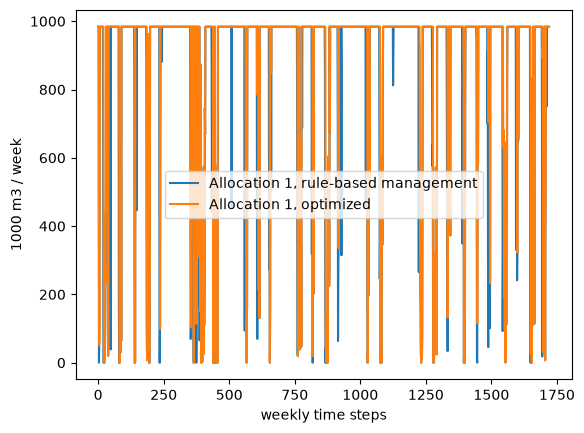

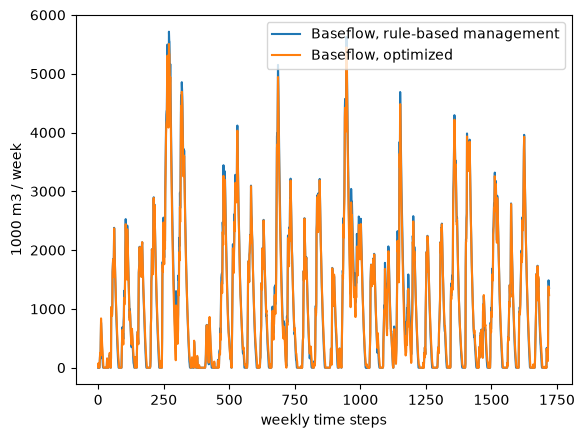

In [6]:
plt.figure()
plt.plot(data['Time step'], data['Allocation 1 (1000 m3 / week)'], label = 'Allocation 1, rule-based management')
plt.plot(data['Time step'], data['Optimal Allocation 1 (1000 m3 / week)'], label = 'Allocation 1, optimized')
plt.xlabel('weekly time steps')
plt.ylabel('1000 m3 / week')
plt.legend()
plt.show()

plt.figure()
plt.plot(data['Time step'], data['Baseflow (1000 m3 / week)'], label = 'Baseflow, rule-based management')
plt.plot(data['Time step'], data['Optimal Baseflow (1000 m3 / week)'], label = 'Baseflow, optimized')
plt.xlabel('weekly time steps')
plt.ylabel('1000 m3 / week')
plt.legend()
plt.show()